In [160]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [161]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [162]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [163]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [164]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (160827741753)>


In [165]:
# -----------------------------------------------------------
# Wipe previous model
ops.wipe()

# --------------------------
# User-defined parameters
matOpt = 1     # 1 = pressure dependent; 2 = pressure independent
fmass = 1.0    # fluid mass density
smass = 2.0    # saturated soil mass density
G = 9.0e4
B = 2.2e5
bulk = 2.2e6   # fluid-solid combined bulk modulus
vperm = 5.e-6  # vertical permeability (m/s)
hperm = vperm  # horizontal permeability (m/s)

accGravity = 9.81  # acceleration of gravity

# Convert permeability to computational value
vperm = vperm / accGravity / fmass
hperm = hperm / accGravity / fmass

loadBias = 0.0     # Static shear load % of gravity load

accMul = 2.0       # acceleration multiplier
period = 1.0       # sine wave period
deltaT = 0.01      # time step
numSteps = 10000    # number of time steps
gamma = 0.6        # Newmark integration parameter

massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.002

# -----------------------------------------------------------
# Build model for fluid phase (ndf=3)
ops.model('basic', '-ndm', 2, '-ndf', 3)

ops.node(1, 0, 0)
ops.node(2, 2.5, 0)
ops.node(3, 2.5, 2)
ops.node(4, 0, 2)

ops.fix(1, 1, 1, 0)
ops.fix(2, 1, 1, 0)
ops.fix(3, 0, 0, 1)
ops.fix(4, 0, 0, 1)
ops.equalDOF(3, 4, 1, 2)

# -----------------------------------------------------------
# Build model for solid phase (ndf=2)
ops.model('basic', '-ndm', 2, '-ndf', 2)

ops.node(5, 1.25, 0.)
ops.node(6, 2.5, 1)
ops.node(7, 1.25, 2)
ops.node(8, 0, 1)
ops.node(9, 1.25, 1)

ops.fix(5, 1, 1)
ops.equalDOF(3, 7, 1, 2)
ops.equalDOF(6, 8, 1, 2)
ops.equalDOF(6, 9, 1, 2)

# Gravity
gravY = -accGravity
gravX = -gravY * loadBias

# -----------------------------------------------------------
# Define material
if matOpt == 1:
    ops.nDMaterial("PressureDependMultiYield02", 1, 2, 1.8, G, B, 32, 0.1, 80, 0.5,
                   26.0, 0.067, 0.23, 0.06, 0.27)
elif matOpt == 2:
    ops.nDMaterial("PressureIndependMultiYield", 2, 2, 1.8, 4.e4, 2.e5, 40, 0.1)

# -----------------------------------------------------------
# Element definition
# element 9_4_QuadUP eleTag nd1 nd2 nd3 nd4 nd5 nd6 nd7 nd8 nd9 thick matTag bulkDen fMass perm1 perm2 gravX gravY
ops.element("9_4_QuadUP", 1,
            1, 2, 3, 4, 5, 6, 7, 8, 9,
            1.0, 1, bulk, fmass, hperm, vperm, gravX, gravY)

# Set material to elastic stage for gravity loading
ops.updateMaterialStage('-material', matOpt, '-stage', 0)

# -----------------------------------------------------------
# Node lists for recorders
SnodeList = [i + 1 for i in range(9)]  # solid phase nodes
FnodeList = [i + 1 for i in range(4)]  # fluid phase nodes

# -----------------------------------------------------------
# GRAVITY ANALYSIS (elastic)
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1.0e-8, 30, 0)
ops.algorithm("KrylovNewton")
ops.constraints("Penalty", 1.e18, 1.e18)

nw = 1.5
nw2 = (nw + 0.5)**2 / 4
ops.integrator("Newmark", nw, nw2)
ops.analysis("Transient")

ops.analyze(10, 5e3)

# Switch to plastic stage
ops.updateMaterialStage('-material', matOpt, '-stage', 1)

ops.analyze(100, 1.0)



0

In [166]:
ops.printModel()

Current Domain Information
	Current Time: 50100
	Committed Time: 50100
NODE DATA: NumNodes: 9

numComponents: 9

 Node: 1
	Coordinates  : 0 0 
	Disps: -9.00212e-18 -1.4715e-17 934010 
	Velocities   : -2.54887e-29 -1.90119e-33 19.62 
	commitAccels: 9.8198e-31 -3.22042e-33 1.52903e-10 
	 unbalanced Load: 0 0 0 
	ID : 19 20 21 


 Node: 2
	Coordinates  : 2.5 0 
	Disps: 9.00212e-18 -1.4715e-17 934010 
	Velocities   : 2.54838e-29 3.84536e-34 19.62 
	commitAccels: -9.88277e-31 1.75387e-33 1.52903e-10 
	 unbalanced Load: 0 0 0 
	ID : 16 17 18 


 Node: 3
	Coordinates  : 2.5 2 
	Disps: 1.17318e-19 -4.61647e-05 2.10746e-33 
	Velocities   : 5.13454e-20 1.61647e-15 -7.84286e-35 
	commitAccels: -1.21468e-20 -6.25528e-17 3.12275e-36 
	 unbalanced Load: 0 0 0 
	ID : 13 14 15 


 Node: 4
	Coordinates  : 0 2 
	Disps: 1.17318e-19 -4.61647e-05 2.10746e-33 
	Velocities   : 5.13454e-20 1.61647e-15 -7.84283e-35 
	commitAccels: -1.21468e-20 -6.25528e-17 3.12326e-36 
	 unbalanced Load: 0 0 0 
	ID : 10 11 12 

In [167]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [168]:
# -----------------------------------------------------------
# Reset time
ops.wipeAnalysis()
ops.setTime(0.0)

# -----------------------------------------------------------
# Apply base motion (Sine wave)
ops.wipeAnalysis()
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, 0.1, 0.0, 0.0)
# ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
# ops.pattern("UniformExcitation", 1, 1, "-accel",1)

# Recorders
ops.recorder('Node', '-file', 'disp', '-time', '-node', *SnodeList, '-dof', 1, 2, '-dT', deltaT, 'disp')
ops.recorder('Node', '-file', 'pwp', '-time', '-node', *FnodeList, '-dof', 3, '-dT', deltaT, 'vel')
ops.recorder('Node', '-file', 'acc', '-time', '-node', *SnodeList, '-dof', 1, 2, '-dT', deltaT, 'accel')

ops.recorder('Element', '-ele', 1, '-time', '-file', 'stress1', '-dT', deltaT, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'strain1', '-dT', deltaT, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'stress5', '-dT', deltaT, 'material', 5, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'strain5', '-dT', deltaT, 'material', 5, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'stress9', '-dT', deltaT, 'material', 9, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'strain9', '-dT', deltaT, 'material', 9, 'strain')

# -----------------------------------------------------------
# DYNAMIC ANALYSIS
ops.constraints("Penalty", 1.e18, 1.e18)
ops.test("NormDispIncr", 1.e-4, 25, 0)
ops.numberer("RCM")
ops.algorithm("KrylovNewton")
ops.system("ProfileSPD")
ops.integrator("Newmark", gamma, (gamma + 0.5)**2 / 4)
ops.rayleigh(massProportionalDamping, 0.0, InitStiffnessProportionalDamping, 0.0)
ops.analysis("VariableTransient")

startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 15)
endT = tt.time()

print(f"Execution time: {endT - startT} seconds")

# Wipe model
ops.wipe()

Execution time: 1.689911127090454 seconds


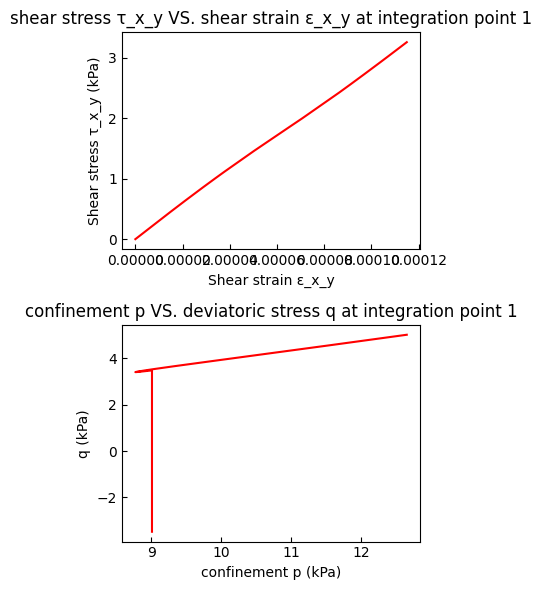

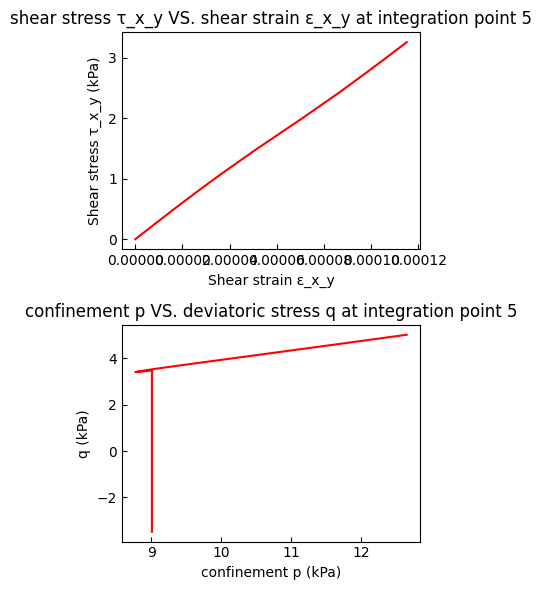

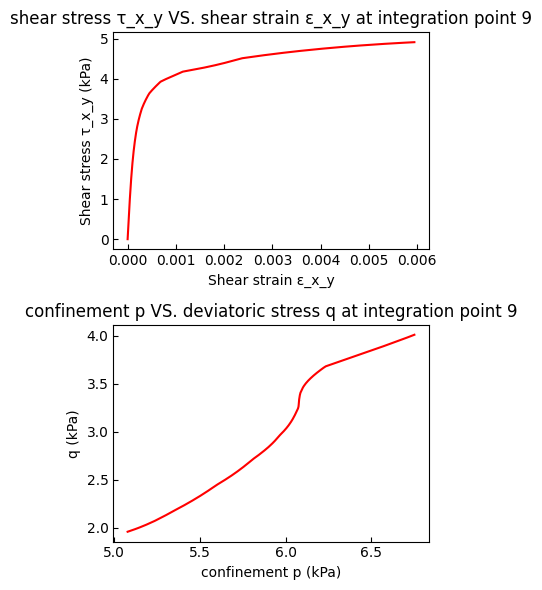

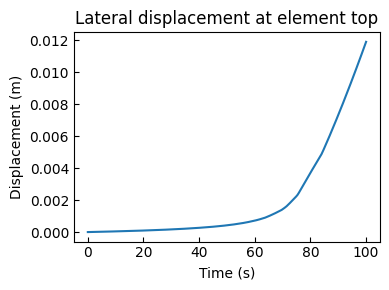

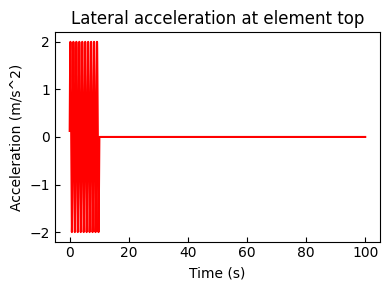

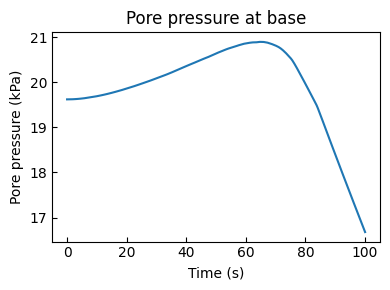

In [169]:
# path: convert_matlab_to_python.py

import numpy as np
import matplotlib.pyplot as plt

# Load data
a1 = np.loadtxt('acc')
d1 = np.loadtxt('disp')
p1 = np.loadtxt('pwp')
s1 = np.loadtxt('stress1')
e1 = np.loadtxt('strain1')
s5 = np.loadtxt('stress5')
e5 = np.loadtxt('strain5')
s9 = np.loadtxt('stress9')
e9 = np.loadtxt('strain9')

# Figure size configs
fs = [0.5, 0.2, 4, 6]
fs2 = [0.5, 0.2, 4, 3]
accMul = 2

# Function to compute po, qo
def compute_pq(stress):
    po = (stress[:, 1] + stress[:, 2] + stress[:, 3]) / 3
    qo = np.sign(stress[:, 4]) * (1 / 3.0) * np.sqrt(
        (stress[:, 1] - stress[:, 2]) ** 2 +
        (stress[:, 2] - stress[:, 3]) ** 2 +
        (stress[:, 1] - stress[:, 3]) ** 2 +
        6.0 * stress[:, 4] ** 2
    )
    return po, qo

# Integration point 1
po, qo = compute_pq(s1)
plt.figure(1, figsize=(fs[2], fs[3]))
plt.subplot(2, 1, 1)
plt.plot(e1[:, 3], s1[:, 4], 'r')
plt.title('shear stress τ_x_y VS. shear strain ε_x_y at integration point 1')
plt.xlabel('Shear strain ε_x_y')
plt.ylabel('Shear stress τ_x_y (kPa)')
plt.subplot(2, 1, 2)
plt.plot(-po, qo, 'r')
plt.title('confinement p VS. deviatoric stress q at integration point 1')
plt.xlabel('confinement p (kPa)')
plt.ylabel('q (kPa)')
plt.tight_layout()
plt.savefig('SS_PQ_p1.jpg')

# Integration point 5
po, qo = compute_pq(s5)
plt.figure(5, figsize=(fs[2], fs[3]))
plt.subplot(2, 1, 1)
plt.plot(e5[:, 3], s5[:, 4], 'r')
plt.title('shear stress τ_x_y VS. shear strain ε_x_y at integration point 5')
plt.xlabel('Shear strain ε_x_y')
plt.ylabel('Shear stress τ_x_y (kPa)')
plt.subplot(2, 1, 2)
plt.plot(-po, qo, 'r')
plt.title('confinement p VS. deviatoric stress q at integration point 5')
plt.xlabel('confinement p (kPa)')
plt.ylabel('q (kPa)')
plt.tight_layout()
plt.savefig('SS_PQ_p5.jpg')

# Integration point 9
po, qo = compute_pq(s9)
plt.figure(6, figsize=(fs[2], fs[3]))
plt.subplot(2, 1, 1)
plt.plot(e9[:, 3], s9[:, 4], 'r')
plt.title('shear stress τ_x_y VS. shear strain ε_x_y at integration point 9')
plt.xlabel('Shear strain ε_x_y')
plt.ylabel('Shear stress τ_x_y (kPa)')
plt.subplot(2, 1, 2)
plt.plot(-po, qo, 'r')
plt.title('confinement p VS. deviatoric stress q at integration point 9')
plt.xlabel('confinement p (kPa)')
plt.ylabel('q (kPa)')
plt.tight_layout()
plt.savefig('SS_PQ_p9.jpg')

# Node displacement
plt.figure(2, figsize=(fs2[2], fs2[3]))
plt.plot(d1[:, 0], d1[:, 5])
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.tight_layout()
plt.savefig('Disp.jpg')

# Synthetic sine wave
s = accMul * np.sin(np.arange(0, 20 * np.pi + np.pi / 50, np.pi / 50))
s = np.concatenate([s, np.zeros(3000)])
s1_interp = np.interp(a1[:, 0], np.arange(0, 40.01, 0.01), s)

# Node acceleration
plt.figure(3, figsize=(fs2[2], fs2[3]))
plt.plot(a1[:, 0], s1_interp + a1[:, 5], 'r')
plt.title('Lateral acceleration at element top')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.tight_layout()
plt.savefig('Acc.jpg')

# Pore pressure at base
plt.figure(4, figsize=(fs2[2], fs2[3]))
plt.plot(p1[:, 0], p1[:, 1])
plt.title('Pore pressure at base')
plt.xlabel('Time (s)')
plt.ylabel('Pore pressure (kPa)')
plt.tight_layout()
plt.savefig('EPWP.jpg')
